In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [246]:
# Чтение и подготовка данных (как в исходном коде)
train_df = pd.read_csv('hw_3/train_oil.csv')
test_df = pd.read_csv('hw_3/oil_test.csv')

display(train_df)
train_df.info()

train_df['Onshore/Offshore'].value_counts()

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,HIDES,IMBURU-TORO,PAPUA NEW GUINEA,FAR EAST,PAPUAN FTB,COMPRESSION,-6.0136,142.8409,OIL SEARCH LTD,ONSHORE,GAS-CONDENSATE,CONTINUING DEVELOPMENT,THRUST,9905,JURASSIC-CRETACEOUS,SANDSTONE,490.0,240.0,10.0,100.0
305,DRAKE POINT,DRAKE POINT-INTREPID INLET,CANADA,NORTH AMERICA,SVERDRUP,COMPRESSION/EVAPORITE/EXTENSION/LINKED,76.4462,-108.9172,PANARCTIC OILS,ONSHORE,GAS,UNDEVELOPED,FORELAND,3390,JURASSIC,SANDSTONE,100.0,71.0,20.0,566.0
306,ALTAMONT-BLUEBELL,GREEN RIVER AND COLTON/WASATCH,USA,NORTH AMERICA,UINTA,COMPRESSION,40.3000,-110.2100,NUMEROUS,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,15250,PALEOGENE,SANDSTONE,8000.0,575.0,5.0,0.1
307,BELL CREEK,MUDDY,USA,NORTH AMERICA,POWDER RIVER,COMPRESSION,45.1039,-105.0967,SAMUEL GARY,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,4300,CRETACEOUS,SANDSTONE,45.0,23.0,28.5,2250.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    object 
 1   Reservoir unit                  309 non-null    object 
 2   Country                         282 non-null    object 
 3   Region                          271 non-null    object 
 4   Basin name                      271 non-null    object 
 5   Tectonic regime                 309 non-null    object 
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    object 
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    object 
 11  Reservoir status                309 non-null    object 
 12  Structural setting              309 

Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64

In [247]:
test_df['Onshore/Offshore'] = np.nan  # Добавляем целевую переменную в test
combined_df = pd.concat([train_df, test_df], ignore_index=True)

# Заполнение пропусков в числовых признаках
numeric_columns = ['Latitude', 'Longitude']

for col in numeric_columns:
    if col in combined_df.columns:
        combined_df[col].fillna(combined_df[col].median(), inplace=True)

categorical_columns = ['Field name', 'Reservoir unit', 'Country', 'Region', 'Basin name', 'Tectonic regime', 'Operator company',
                     'Hydrocarbon type', 'Reservoir status', 'Structural setting',
                     'Reservoir period', 'Lithology']

combined_encoded = combined_df.copy()

def create_features(df):
    # Отношение нетолстой толщины к общей
    df['thickness_ratio'] = df['Thickness (net pay average ft)'] / df['Thickness (gross average ft)']
    df['thickness_ratio'].fillna(0, inplace=True)
    df['thickness_ratio'].replace([np.inf, -np.inf], 0, inplace=True)
    
    # Производительность резервуара (приблизительная)
    df['reservoir_productivity'] = df['Porosity'] * df['Permeability']
    
    df['depth_category'] = pd.cut(df['Depth'], 
                                bins=[0, 1000, 3000, 5000, 9000, 15000, 20000],
                                labels=[1, 2, 3, 4, 5, 6])
    df['depth_category'].fillna(3, inplace=True)
    
    return df

combined_encoded = create_features(combined_encoded)

# Label Encoding для категориальных признаков
label_encoders = {}
for col in categorical_columns:
    if col in combined_encoded.columns:
        le = LabelEncoder()
        all_values = combined_encoded[col].astype(str).values
        le.fit(all_values)
        combined_encoded[col] = le.transform(combined_encoded[col].astype(str))
        label_encoders[col] = le

# One-Hot Encoding для основных категориальных признаков
categorical_for_onehot = ['Region', 'Hydrocarbon type', 'Reservoir status', 'Structural setting']
combined_encoded = pd.get_dummies(combined_encoded, columns=categorical_for_onehot, 
                                prefix=categorical_for_onehot, drop_first=True)

# for col in combined_encoded.columns:
#     if combined_encoded[col].dtype == 'object':
#         combined_encoded[col] = pd.to_numeric(combined_encoded[col], errors='coerce')
# combined_encoded[['Field name', 'Reservoir unit', 'Country']] = combined_encoded[['Field name', 'Reservoir unit', 'Country']].astype(str)
# combined_encoded.loc[combined_encoded['Onshore/Offshore'] == 'ONSHORE', 'Onshore/Offshore'] = 1
# combined_encoded.loc[combined_encoded['Onshore/Offshore'] == 'OFFSHORE', 'Onshore/Offshore'] = 0

combined_encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 95 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Field name                      442 non-null    int32   
 1   Reservoir unit                  442 non-null    int32   
 2   Country                         442 non-null    int32   
 3   Basin name                      442 non-null    int32   
 4   Tectonic regime                 442 non-null    int32   
 5   Latitude                        442 non-null    float64 
 6   Longitude                       442 non-null    float64 
 7   Operator company                442 non-null    int32   
 8   Onshore/Offshore                309 non-null    object  
 9   Depth                           442 non-null    int64   
 10  Reservoir period                442 non-null    int32   
 11  Lithology                       442 non-null    int32   
 12  Thickness (gross avera

In [248]:
train_processed = combined_encoded[combined_encoded['Onshore/Offshore'].notna()].copy()
test_processed = combined_encoded[combined_encoded['Onshore/Offshore'].isna()].copy()

target_encoder = LabelEncoder()
train_processed['target_encoded'] = target_encoder.fit_transform(train_processed['Onshore/Offshore'])
train_processed = train_processed.drop(['Field name', 'Reservoir unit', 'Country', 'Onshore/Offshore'], axis=1)
test_processed = test_processed.drop(['Field name', 'Reservoir unit', 'Country', 'Onshore/Offshore'], axis=1)

scaler = StandardScaler()
numeric_features = ['Latitude', 'Longitude', 'Depth', 'Thickness (gross average ft)',
                   'Thickness (net pay average ft)', 'Porosity', 'Permeability',
                   'thickness_ratio', 'reservoir_productivity', 'depth_category']

train_processed[numeric_features] = scaler.fit_transform(train_processed[numeric_features])
test_processed[numeric_features] = scaler.transform(test_processed[numeric_features])

X_train = train_processed.drop(['target_encoded'], axis=1)
y_train = train_processed['target_encoded']
X_test = test_processed

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, 
                                          random_state=42, stratify=y_train)

bool_columns = X_tr.select_dtypes(include=['bool']).columns
print(f"\nНайдено {len(bool_columns)} булевых колонок\n")

for col in bool_columns:
    X_tr[col] = X_tr[col].astype(int)
    X_val[col] = X_val[col].astype(int)
    X_test[col] = X_test[col].astype(int)

X_tr.info()

Размер обучающей выборки: (309, 91)
Размер тестовой выборки: (133, 91)

Найдено 76 булевых колонок

<class 'pandas.core.frame.DataFrame'>
Index: 247 entries, 88 to 20
Data columns (total 91 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Basin name                      247 non-null    int32  
 1   Tectonic regime                 247 non-null    int32  
 2   Latitude                        247 non-null    float64
 3   Longitude                       247 non-null    float64
 4   Operator company                247 non-null    int32  
 5   Depth                           247 non-null    float64
 6   Reservoir period                247 non-null    int32  
 7   Lithology                       247 non-null    int32  
 8   Thickness (gross average ft)    247 non-null    float64
 9   Thickness (net pay average ft)  247 non-null    float64
 10  Porosity                        247 non-null    float64
 11  Pe

In [249]:
# Преобразование в тензоры PyTorch
X_train_tensor = torch.tensor(X_tr.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_tr.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

class ClassificationNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(ClassificationNN, self).__init__()
        self.layer1 = nn.Linear(input_dim, 32)
        self.layer2 = nn.Linear(32, 64)
        self.layer3 = nn.Linear(64, 32)
        self.layer4 = nn.Linear(32, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.batchnorm1 = nn.BatchNorm1d(32)
        self.batchnorm2 = nn.BatchNorm1d(64)
        self.batchnorm3 = nn.BatchNorm1d(32)
        
    def forward(self, x):
        x = self.relu(self.batchnorm1(self.layer1(x)))
        x = self.relu(self.batchnorm2(self.layer2(x)))
        x = self.relu(self.batchnorm3(self.layer3(x)))
        x = self.layer4(x)
        return x

In [ ]:
input_dim = X_train.shape[1]
num_classes = len(target_encoder.classes_)
model = ClassificationNN(input_dim, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

num_epochs = 150
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_accuracy = 0
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = train_correct / train_total
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    scheduler.step(avg_val_loss)
    
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_state = model.state_dict().copy()
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, '
              f'Train Acc: {train_accuracy:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

model.load_state_dict(best_model_state)

Epoch [20/150], Train Loss: 0.1596, Train Acc: 0.9717, Val Loss: 0.5418, Val Acc: 0.8226
Epoch [40/150], Train Loss: 0.0891, Train Acc: 0.9798, Val Loss: 0.4994, Val Acc: 0.8710
Epoch [60/150], Train Loss: 0.0724, Train Acc: 0.9757, Val Loss: 0.5395, Val Acc: 0.8710
Epoch [80/150], Train Loss: 0.0664, Train Acc: 0.9798, Val Loss: 0.5418, Val Acc: 0.8548
Epoch [100/150], Train Loss: 0.0632, Train Acc: 0.9757, Val Loss: 0.5444, Val Acc: 0.8548
Epoch [120/150], Train Loss: 0.0592, Train Acc: 0.9838, Val Loss: 0.5401, Val Acc: 0.8548
Epoch [140/150], Train Loss: 0.0676, Train Acc: 0.9798, Val Loss: 0.5444, Val Acc: 0.8548


<All keys matched successfully>


Лучшая точность модели на валидационной выборке: 0.8548

Отчет по классификации:
                  precision    recall  f1-score   support

        OFFSHORE       0.80      0.71      0.75        17
         ONSHORE       0.87      0.93      0.90        44
ONSHORE-OFFSHORE       0.00      0.00      0.00         1

        accuracy                           0.85        62
       macro avg       0.56      0.55      0.55        62
    weighted avg       0.84      0.85      0.85        62



c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

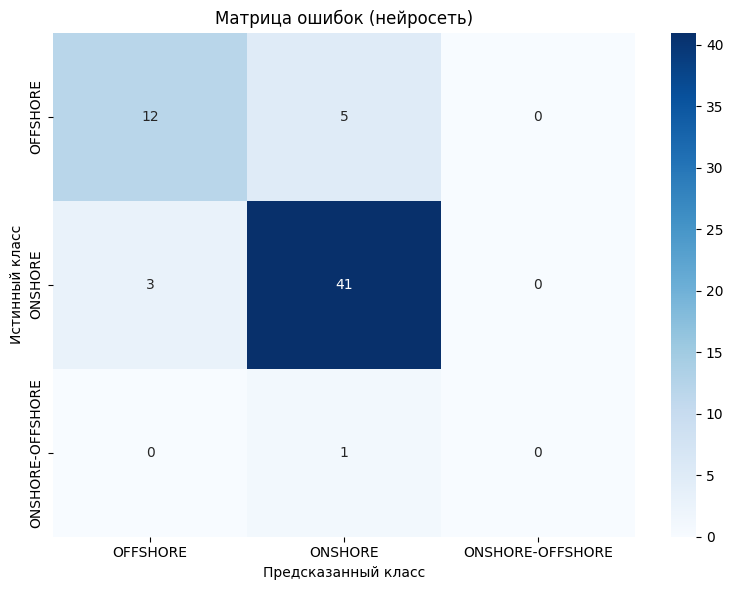

In [251]:
model.eval()
with torch.no_grad():
    val_outputs = model(X_val_tensor)
    _, val_predictions = torch.max(val_outputs.data, 1)
    val_predictions_np = val_predictions.numpy()
    y_val_np = y_val.values

accuracy = accuracy_score(y_val_np, val_predictions_np)
print(f"\n" + "="*60)
print(f"Лучшая точность модели на валидационной выборке: {accuracy:.4f}")
print("="*60)
print("\nОтчет по классификации:")
print(classification_report(y_val_np, val_predictions_np, target_names=target_encoder.classes_))

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val_np, val_predictions_np)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_encoder.classes_, 
            yticklabels=target_encoder.classes_)
plt.title('Матрица ошибок (нейросеть)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

In [255]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, test_predictions = torch.max(test_outputs.data, 1)
    test_predictions_np = test_predictions.numpy()
    
    # Обратное преобразование меток
    test_predictions_original = target_encoder.inverse_transform(test_predictions_np)

test_predictions_original = np.where(test_predictions_original == 'ONSHORE', 1, test_predictions_original)
test_predictions_original = np.where(test_predictions_original == 'OFFSHORE', 0, test_predictions_original)
test_predictions_original = np.where(test_predictions_original == 'ONSHORE-OFFSHORE', 2, test_predictions_original)
print(test_predictions_original)

[1 0 1 0 1 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 1 0 1 1 1 0 0 0 1 0 1 1 1 1 1 0 1
 1 1 0 0 1 0 1 0 1 0 1 1 1 0 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 0 0 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 0 1 1 1 1
 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1]


In [257]:
np.savetxt(
    'hw_3/test_pred.csv',          # Имя файла
    np.column_stack((np.arange(len(test_predictions)), test_predictions)),  # Данные: индексы и значения
    delimiter=',',          # Разделитель - запятая
    header='index,Rating Average',  # Заголовок
    comments='',           # Убрать символ '#' перед заголовком
    fmt=['%d', '%i']    # Форматы: целые числа для индекса, float с 2 знаками для оценок
)

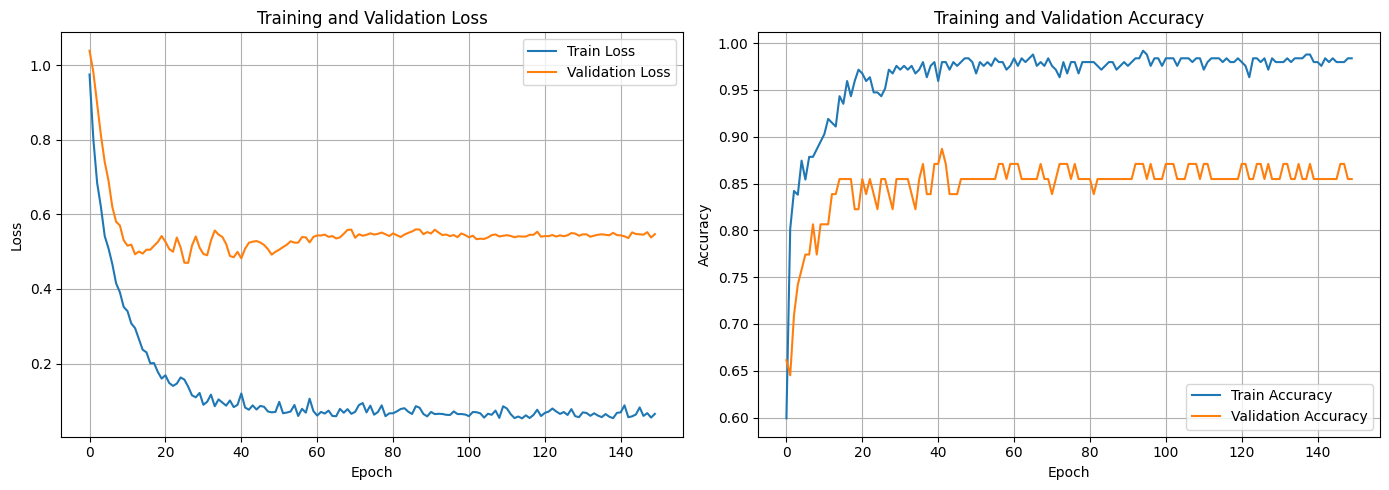

In [253]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()